<a href="https://colab.research.google.com/github/shankar-011/GenAI-Internship/blob/master/DAY5/nlp(assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
df = pd.read_csv("reviews_data.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
       name           location                     Date  Rating  \
0     Helen  Wichita Falls, TX  Reviewed Sept. 13, 2023     5.0   
1  Courtney         Apopka, FL   Reviewed July 16, 2023     5.0   
2  Daynelle  Cranberry Twp, PA    Reviewed July 5, 2023     5.0   
3    Taylor        Seattle, WA    Reviewed May 26, 2023     5.0   
4   Tenessa        Gresham, OR   Reviewed Jan. 22, 2023     5.0   

                                              Review  \
0  Amber and LaDonna at the Starbucks on Southwes...   
1  ** at the Starbucks by the fire station on 436...   
2  I just wanted to go out of my way to recognize...   
3  Me and my friend were at Starbucks and my card...   
4  I’m on this kick of drinking 5 cups of warm wa...   

                                         Image_Links  
0                                      ['No Images']  
1                                      ['No Images']  
2  ['https://media.consumeraffairs.com/files/cach...  
3                         

In [55]:
df['Review']

,Review
0,Amber and LaDonna at the Starbucks on Southwes...
1,** at the Starbucks by the fire station on 436...
2,I just wanted to go out of my way to recognize...
3,Me and my friend were at Starbucks and my card...
4,I’m on this kick of drinking 5 cups of warm wa...
...,...
845,I ordered two venti frappacino's without whipp...
846,No Review Text
847,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL..."
848,No Review Text


In [56]:
reviews = df["Review"]


lower_reviews = reviews.str.lower()

print("Original:")
print(reviews.iloc[0])

print("\nLowercase:")
print(lower_reviews.iloc[0])

Original:
Amber and LaDonna at the Starbucks on Southwest Parkway are always so warm and welcoming. There is always a smile in their voice when they greet you at the drive-thru. And their customer service is always spot-on, they always get my order right and with a smile. I would actually give them more than 5 stars if they were available.

Lowercase:
amber and ladonna at the starbucks on southwest parkway are always so warm and welcoming. there is always a smile in their voice when they greet you at the drive-thru. and their customer service is always spot-on, they always get my order right and with a smile. i would actually give them more than 5 stars if they were available.


In [57]:
tokens = lower_reviews.apply(word_tokenize)

print("\nFirst 5 tokenized samples:")
for i in range(5):
    print(tokens.iloc[i])


First 5 tokenized samples:
['amber', 'and', 'ladonna', 'at', 'the', 'starbucks', 'on', 'southwest', 'parkway', 'are', 'always', 'so', 'warm', 'and', 'welcoming', '.', 'there', 'is', 'always', 'a', 'smile', 'in', 'their', 'voice', 'when', 'they', 'greet', 'you', 'at', 'the', 'drive-thru', '.', 'and', 'their', 'customer', 'service', 'is', 'always', 'spot-on', ',', 'they', 'always', 'get', 'my', 'order', 'right', 'and', 'with', 'a', 'smile', '.', 'i', 'would', 'actually', 'give', 'them', 'more', 'than', '5', 'stars', 'if', 'they', 'were', 'available', '.']
['*', '*', 'at', 'the', 'starbucks', 'by', 'the', 'fire', 'station', 'on', '436', 'in', 'altamonte', 'springs', ',', 'fl', 'made', 'my', 'day', 'and', 'finally', 'helped', 'me', 'figure', 'out', 'the', 'way', 'to', 'make', 'my', 'drink', 'so', 'i', '’', 'd', 'love', 'it', '.', 'she', 'took', 'time', 'out', 'to', 'talk', 'to', 'me', 'for', '2', 'minutes', 'to', 'make', 'my', 'experience', 'better', 'than', 'what', 'i', '’', 'm', 'used',

In [58]:
stop_words = set(stopwords.words("english"))
tokens_no_stopwords = tokens.apply(
    lambda words: [
        word.lower()
        for word in words
        if word.isalpha() and word.lower() not in stop_words
    ]
)
print("\nBefore:")
print(tokens.iloc[0])

print("\nAfter:")
print(tokens_no_stopwords.iloc[0])


Before:
['amber', 'and', 'ladonna', 'at', 'the', 'starbucks', 'on', 'southwest', 'parkway', 'are', 'always', 'so', 'warm', 'and', 'welcoming', '.', 'there', 'is', 'always', 'a', 'smile', 'in', 'their', 'voice', 'when', 'they', 'greet', 'you', 'at', 'the', 'drive-thru', '.', 'and', 'their', 'customer', 'service', 'is', 'always', 'spot-on', ',', 'they', 'always', 'get', 'my', 'order', 'right', 'and', 'with', 'a', 'smile', '.', 'i', 'would', 'actually', 'give', 'them', 'more', 'than', '5', 'stars', 'if', 'they', 'were', 'available', '.']

After:
['amber', 'ladonna', 'starbucks', 'southwest', 'parkway', 'always', 'warm', 'welcoming', 'always', 'smile', 'voice', 'greet', 'customer', 'service', 'always', 'always', 'get', 'order', 'right', 'smile', 'would', 'actually', 'give', 'stars', 'available']


In [59]:
stemmer = PorterStemmer()

stemmed = tokens_no_stopwords.apply(lambda words: [stemmer.stem(word) for word in words])

lemmatizer = WordNetLemmatizer()

lemmatized = tokens_no_stopwords.apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

In [60]:
clean_text = lemmatized.apply(lambda words: " ".join(words))
clean_df = pd.DataFrame({
    "clean_text": clean_text
})

clean_df.to_csv("clean_reviews.csv", index=False)

print("Saved as clean_reviews.csv")

Saved as clean_reviews.csv


In [61]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(clean_text)
bow_df = pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bag of Words Matrix:")
print(bow_df)

Bag of Words Matrix:
     abaya  abaza  abbotsford  abdominal  aberdeen  ability  able  abroad  \
0        0      0           0          0         0        0     0       0   
1        0      0           0          0         0        0     0       0   
2        0      0           0          0         0        0     0       0   
3        0      0           0          0         0        0     0       0   
4        0      0           0          0         0        0     0       0   
..     ...    ...         ...        ...       ...      ...   ...     ...   
845      0      0           0          0         0        0     0       0   
846      0      0           0          0         0        0     0       0   
847      0      0           0          0         0        0     0       0   
848      0      0           0          0         0        0     0       0   
849      0      0           0          0         0        0     0       0   

     absolute  absolutely  ...  yous  youth  youtube  

In [62]:
print("Vocabulary Size:", len(vectorizer.vocabulary_))

print("\nShape:")
print(bow_matrix.shape)

print("\nFirst 10 Feature Names:")
print(vectorizer.get_feature_names_out()[:10])

Vocabulary Size: 4986

Shape:
(850, 4986)

First 10 Feature Names:
['abaya' 'abaza' 'abbotsford' 'abdominal' 'aberdeen' 'ability' 'able'
 'abroad' 'absolute' 'absolutely']


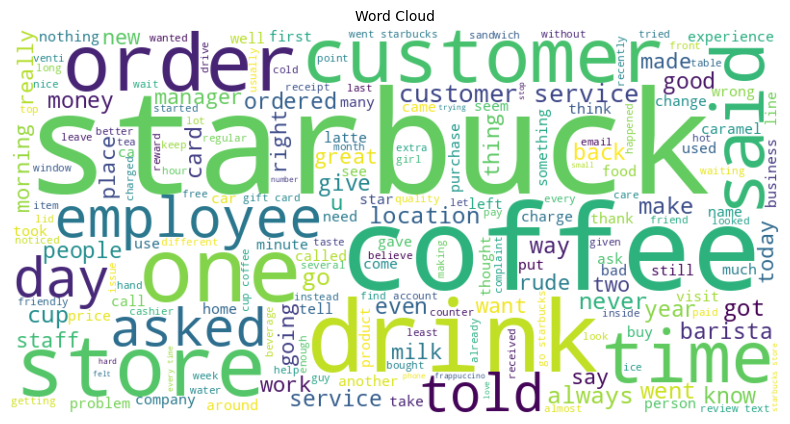

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text_data=" ".join(clean_text)
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud',fontsize=10)
plt.show()